# Ejercicios de clase

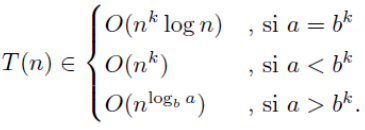

## Dado un array A y un elemento K, contar cuántas veces está K en A.

In [ ]:
def count_occurrences(arr, k):
  #conquer
  if(len(arr) == 1):
    if(arr[0] == k):
      return 1
    else:
      return 0

  #divide
  mid = len(arr) // 2
  cl = count_occurrences(arr[:mid], k)
  cr = count_occurrences(arr[mid:], k)

  #combine
  return cl + cr

count_occurrences([2,2,2,23,3,2],2)

4

## Dado un array A y un elemento K, definir si K está en A.

In [ ]:
def is_k_in_arr(arr, k):
  #conquer
  if(len(arr) == 1):
    if(arr[0] == k):
      return True
    else:
      return False

  #divide
  mid = len(arr) // 2
  cl = is_k_in_arr(arr[:mid], k)
  cr = is_k_in_arr(arr[mid:], k)

  #combine
  return cl or cr

is_k_in_arr([2,2,2,23,3,2],2)

True

# 📝 **Enunciado:**

Se te da un arreglo de enteros `nums` y un entero `k`. Tu tarea es devolver el **k-ésimo elemento más grande** en el arreglo.

Ten en cuenta que se refiere al **k-ésimo elemento más grande en el orden ordenado** del arreglo, **no** al k-ésimo elemento distinto.

💡 **Reto adicional:** Intenta resolverlo **sin ordenar** el arreglo completo.

---

**Ejemplo 1:**

```
Entrada: nums = [3,2,1,5,6,4], k = 2  
Salida: 5  
```

**Ejemplo 2:**

```
Entrada: nums = [3,2,3,1,2,4,5,5,6], k = 4  
Salida: 4  
```

---

**Restricciones:**

* 1 <= k <= nums.length <= 10⁵
* -10⁴ <= nums\[i] <= 10⁴

---
Leetcode 215


In [ ]:
from typing import List
import random

def kth_largest_copying(nums: List[int], k: int) -> int:
    """
    Devuelve el k-ésimo elemento más grande SIN swaps in-place.
    En cada paso:
      - Elige un pivote aleatorio.
      - Particiona en listas nuevas: gt (>pivote), eq (==pivote), lt (<pivote).
      - Decide en cuál sublista está el k-ésimo más grande y recurre.

    Complejidad esperada:
      - Tiempo: O(n) promedio, O(n^2) peor caso (pivotes muy desbalanceados).
      - Memoria: O(n) adicional por las copias (gt, eq, lt) en cada nivel.
    """
    n = len(nums)
    if not (1 <= k <= n):
        raise ValueError("k fuera de rango")

    # Caso base rápido
    if n == 1:
        return nums[0]

    pivot = random.choice(nums)

    gt = [x for x in nums if x > pivot]
    eq = [x for x in nums if x == pivot]
    lt = [x for x in nums if x < pivot]

    if k <= len(gt):
        return kth_largest_copying(gt, k)
    if k <= len(gt) + len(eq):
        return pivot
    # está en los menores; ajustamos k restando los elementos mayores y los iguales
    return kth_largest_copying(lt, k - len(gt) - len(eq))


In [ ]:
assert kth_largest_copying([3,2,1,5,6,4], 2) == 5
assert kth_largest_copying([3,2,3,1,2,4,5,5,6], 4) == 4

In [ ]:
from typing import List
import random

def find_kth_largest(nums: List[int], k: int) -> int:
    """
    Devuelve el k-ésimo elemento más grande usando Quickselect.
    - Promedio: O(n)
    - Peor caso: O(n^2) (mitigado usando pivote aleatorio)
    - Memoria extra: O(1) si se permite mutar el arreglo (aquí copiamos para no mutar)
    """
    arr = nums[:]                  # opcional: copia para no mutar la entrada
    n = len(arr)
    target = n - k                 # índice que tendría el k-ésimo más grande en orden ascendente

    def partition(lo: int, hi: int, p_idx: int) -> int:
        """Partición de Lomuto alrededor del valor pivote arr[p_idx]."""
        pivot_val = arr[p_idx]
        arr[p_idx], arr[hi] = arr[hi], arr[p_idx]  # mover pivote al final
        store = lo
        for i in range(lo, hi):
            if arr[i] < pivot_val:
                arr[store], arr[i] = arr[i], arr[store]
                store += 1
        arr[store], arr[hi] = arr[hi], arr[store]  # devolver pivote a su lugar final
        return store

    lo, hi = 0, n - 1
    while lo <= hi:
        p_idx = random.randint(lo, hi)     # pivote aleatorio para evitar peores casos sistemáticos
        mid = partition(lo, hi, p_idx)
        if mid == target:
            return arr[mid]
        elif mid < target:
            lo = mid + 1
        else:
            hi = mid - 1

    # Por restricciones, k es válido; nunca deberíamos llegar aquí.
    raise RuntimeError("Estado inesperado en Quickselect.")


In [ ]:
from typing import List
import heapq

def find_kth_largest_heap(nums: List[int], k: int) -> int:
    """
    Devuelve el k-ésimo elemento más grande usando un heap mínimo de tamaño k.
    - Tiempo: O(n log k)
    - Memoria: O(k)
    - No ordena todo el arreglo.
    """
    h: List[int] = []
    for x in nums:
        if len(h) < k:
            heapq.heappush(h, x)
        elif x > h[0]:
            heapq.heapreplace(h, x)
    return h[0]


In [ ]:
assert find_kth_largest([3,2,1,5,6,4], 2) == 5
assert find_kth_largest([3,2,3,1,2,4,5,5,6], 4) == 4

assert find_kth_largest_heap([3,2,1,5,6,4], 2) == 5
assert find_kth_largest_heap([3,2,3,1,2,4,5,5,6], 4) == 4

In [ ]:
from typing import List
import random

def kth_largest_quickselect_inline(nums: List[int], k: int) -> int:
    """
    Devuelve el k-ésimo elemento más grande sin ordenar todo el arreglo.
    Implementación monolítica: copia, elige pivote y particiona en la MISMA función.

    Complejidad:
      - Tiempo: O(n) promedio, O(n^2) peor caso.
      - Espacio extra: O(1) (además de la copia O(n) para no mutar la entrada).
    """
    n = len(nums)
    if not (1 <= k <= n):
        raise ValueError("k fuera de rango")

    arr = nums[:]         # copiamos para no mutar entrada
    target = n - k        # índice del k-ésimo más grande en orden ascendente

    lo, hi = 0, n - 1
    while lo <= hi:
        # --- seleccionar pivote aleatorio ---
        p_idx = random.randint(lo, hi)
        pivot_val = arr[p_idx]
        # mover pivote al final
        arr[p_idx], arr[hi] = arr[hi], arr[p_idx]

        # --- partición de Lomuto (inline) ---
        store = lo
        for i in range(lo, hi):
            if arr[i] < pivot_val:
                arr[store], arr[i] = arr[i], arr[store]
                store += 1
        # poner pivote en su lugar final
        arr[store], arr[hi] = arr[hi], arr[store]

        # --- decidir siguiente rango ---
        if store == target:
            return arr[store]
        elif store < target:
            lo = store + 1
        else:
            hi = store - 1

    # Por las restricciones, no debería alcanzarse
    raise RuntimeError("Estado inesperado en Quickselect")


In [ ]:
assert kth_largest_quickselect_inline([3,2,1,5,6,4], 2) == 5
assert kth_largest_quickselect_inline([3,2,3,1,2,4,5,5,6], 4) == 4

# 📝 **Enunciado**:

Se define que una cadena $s$ es **agradable** (*nice*) si, para cada letra del alfabeto que contenga, dicha letra aparece **tanto en mayúscula como en minúscula**.
Por ejemplo:

* `"abABB"` es agradable porque para cada letra presente ('a' y 'b'), están sus versiones mayúscula y minúscula ('A', 'a', 'B', 'b').
* `"abA"` **no** es agradable porque 'b' está en minúscula pero no aparece en mayúscula ('B').

Dada una cadena $s$, se debe **retornar la subcadena más larga** que sea agradable.

* Si existen varias subcadenas con la misma longitud, retornar la que **aparezca primero**.
* Si no hay ninguna subcadena agradable, retornar la cadena vacía (`""`).

---

### **Ejemplos**

**Ejemplo 1**
Entrada:

```
s = "YazaAay"
```

Salida:

```
"aAa"
```

Explicación: `"aAa"` es agradable porque 'A/a' es la única letra presente y tiene ambas versiones. Es la subcadena agradable más larga.

---

**Ejemplo 2**
Entrada:

```
s = "Bb"
```

Salida:

```
"Bb"
```

Explicación: `"Bb"` es agradable porque tanto 'B' como 'b' aparecen.

---

**Ejemplo 3**
Entrada:

```
s = "c"
```

Salida:

```
""
```

Explicación: No existe ninguna subcadena agradable.

---

**Restricciones**

* $1 \leq s.length \leq 100$
* $s$ consiste únicamente en letras inglesas mayúsculas y minúsculas.


---
Leetcode 1763

# 📝 **Enunciado del problema**

Se tiene un arreglo de enteros `nums` cuyos elementos están **ordenados en forma ascendente**.
El objetivo es **convertirlo en un Árbol Binario de Búsqueda (BST) equilibrado en altura** (*height-balanced*).

Un **BST equilibrado en altura** es aquel en el que, para cada nodo, la diferencia de alturas entre su subárbol izquierdo y derecho es como máximo 1.

---

### **Ejemplos**

**Ejemplo 1**
Entrada:

```
nums = [-10, -3, 0, 5, 9]
```

Salida:

```
[0, -3, 9, -10, null, 5]
```

Explicación:
Una solución posible es el BST:

```
       0
     /   \
   -3     9
   /     /
-10     5
```

Otra estructura válida también es aceptada, como `[0, -10, 5, null, -3, null, 9]`.

---

**Ejemplo 2**
Entrada:

```
nums = [1, 3]
```

Salida:

```
[3, 1]
```

Explicación:
Se puede construir un árbol equilibrado con raíz `3` y `1` como hijo izquierdo, o con raíz `1` y `3` como hijo derecho.

---

**Restricciones**

* $1 \leq \text{nums.length} \leq 10^4$
* $-10^4 \leq \text{nums}[i] \leq 10^4$
* `nums` está ordenado en **estricto** orden ascendente.

---
Leetcode 108

# Ejercicios más sencillos

# 1) Invertir un string por mitades

## Enunciado

Dado un string `s`, retorna su reverso **usando divide y vencerás**: divide el string en dos mitades, invierte cada mitad recursivamente y **combina** concatenando en orden inverso.

## Entrada / Salida

* Entrada: `s` (1 ≤ |s| ≤ 10⁵)
* Salida: `s` invertida

## Ejemplos

* `s = "abcd"` → `"dcba"`
* `s = "a"` → `"a"`


## Complejidad esperada

* **T(n) = 2·T(n/2) + O(n)** (la combinación concatena).
* **Tiempo:** O(n log n) si concatenas strings ingenuamente; O(n) si combinas de forma eficiente (p. ej., acumulando en una lista y uniendo al final).
* **Espacio:** O(n) por el resultado + profundidad O(log n).

> Sugerencia: Para mantener O(n), acumula en listas y **join** al final

# 2) Mínimo y máximo simultáneos en un arreglo

## Enunciado

Dado un arreglo `nums` de enteros, encuentra **simultáneamente** el mínimo y el máximo usando **divide y vencerás**.

## Entrada / Salida

* Entrada: `nums` (1 ≤ n ≤ 10⁵)
* Salida: una tupla `(min, max)`

## Ejemplos

* `nums = [3, 7, 2, 9]` → `(2, 9)`
* `nums = [5]` → `(5, 5)`


## Complejidad esperada

* **T(n) = 2·T(n/2) + O(1)**
* **Tiempo:** O(n)
* **Espacio:** O(log n) por recursión.


[2, 3, 4, 5, 76, 2, 1]
[2, 3, 4]
[2]
[3, 4]
[3]
[4]
[5, 76, 2, 1]
[5, 76]
[5]
[76]
[2, 1]
[2]
[1]


(76, 1)

[2, 3, 4, 5, 76, 2, 1, 10]
m:3, l:0, r:7, [2, 3, 4, 5, 76, 2, 1, 10]
[2, 3, 4, 5, 76, 2, 1, 10]
m:1, l:0, r:3, [2, 3, 4, 5]
[2, 3, 4, 5, 76, 2, 1, 10]
m:0, l:0, r:1, [2, 3]
[2, 3, 4, 5, 76, 2, 1, 10]
m:0, l:0, r:0, [2]
[2, 3, 4, 5, 76, 2, 1, 10]
m:1, l:1, r:1, [3]
[2, 3, 4, 5, 76, 2, 1, 10]
m:2, l:2, r:3, [4, 5]
[2, 3, 4, 5, 76, 2, 1, 10]
m:2, l:2, r:2, [4]
[2, 3, 4, 5, 76, 2, 1, 10]
m:3, l:3, r:3, [5]
[2, 3, 4, 5, 76, 2, 1, 10]
m:5, l:4, r:7, [76, 2, 1, 10]
[2, 3, 4, 5, 76, 2, 1, 10]
m:4, l:4, r:5, [76, 2]
[2, 3, 4, 5, 76, 2, 1, 10]
m:4, l:4, r:4, [76]
[2, 3, 4, 5, 76, 2, 1, 10]
m:5, l:5, r:5, [2]
[2, 3, 4, 5, 76, 2, 1, 10]
m:6, l:6, r:7, [1, 10]
[2, 3, 4, 5, 76, 2, 1, 10]
m:6, l:6, r:6, [1]
[2, 3, 4, 5, 76, 2, 1, 10]
m:7, l:7, r:7, [10]


(76, 1)

# 3) Suma y conteo de pares/impares en una **matriz** por cuadrantes

## Enunciado

Dada una matriz `M` de enteros `n × n`, devuelve:

1. la **suma total** de todos los elementos
2. el **conteo** de elementos **pares** e **impares**
   usando **divide y vencerás por cuadrantes**.

## Entrada / Salida

* Entrada: `M` de tamaño `n × n` (1 ≤ n ≤ 2ᵏ, 1 ≤ n ≤ 1024)
* Salida: una tupla `(suma, pares, impares)`

## Ejemplos

* `M = [[1,2],[3,4]]` → `(suma=10, pares=2, impares=2)`
* `M = [[0]]` → `(0, 1, 0)`


## Complejidad esperada

* **T(n) = 4·T(n/2) + O(1)**
* **Tiempo:** O(n²) (hay que visitar todas las celdas).
* **Espacio:** O(log n) por profundidad (si procesas por referencias/slices controlados).

> Tip: Evita copiar submatrices grandes; pasa índices (rango de filas/columnas) para mantener el espacio bajo.